In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── File paths ──────────────────────────────────────────────────────────────
INPUT_PATH  = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_augmented.csv")
# OUTPUT_PATH = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_final2.csv")

# thresholds
LENGTH_MIN              = 8    # minimum peptide length (AA) for Class I
LENGTH_MAX              = 12 # maximum — expand to 15 for atypical lengths
MIN_ROWS_PER_ALLELE     = 100    # drop HLA alleles with fewer rows than this
MIN_ROWS_PER_DISEASE    = 100    # drop diseases with fewer rows than this
MAX_CANCER_PER_DISEASE  = 2000   # cap each cancer type at this many rows
MAX_HEALTHY             = 10000  # total healthy rows to keep
TOP_N_FEATURES_BY_SD    = 8      # number of top biochemical features to select

# ── Tissue-disease consistency rules ────────────────────────────────────────
DISEASE_TISSUE_CONSISTENCY = {
    "glioblastoma":      ["brain", "pbmc", "blood"],
    "medulloblastoma":   ["brain", "cerebellum", "pbmc", "blood", "blood_plasma"],
    "meningioma":        ["brain", "pbmc", "blood"],
    "lung":              ["lung", "pbmc", "blood", "lymph"],
    "ovarian":           ["ovary", "pbmc", "blood", "lymph"],
    "renal":             ["kidney", "pbmc", "blood"],
    "hepatocellular":    ["liver", "pbmc", "blood"],
    "melanoma":          ["skin", "pbmc", "blood", "lymph"],
    "breast":            ["mamma", "pbmc", "blood", "lymph"],
    "colorectal":        ["colon", "pbmc", "blood", "lymph"],
    "gastric":           ["stomach", "pbmc", "blood"],
    "pancreatic":        ["pancreas", "pbmc", "blood"],
    "leukemia":          ["pbmc", "blood", "bone_marrow"],
    "lymphoma":          ["pbmc", "blood", "lymph", "bone_marrow"],
    "myeloma":           ["pbmc", "blood", "bone_marrow"],
    "prostate":          ["prostate", "pbmc", "blood"],
    "head and neck":     ["head_and_neck", "pbmc", "blood", "lymph"],
    "thymoma":           ["thymus", "pbmc", "blood"],
}

# ── Biochemical features evaluated for SD-based selection ───────────────────
BIOCHEM_FEATURES = [
    "molecular_weight", "charge_pH_7", "hydrophobicity_GRAVY",
    "isoelectric_point", "aromaticity", "instability_index",
    "helix_fraction", "sheet_fraction", "turn_fraction",
    "flexibility_mean", "aliphatic_index", "boman_index",
    "anchor_p2_hydro", "anchor_pC_hydro", "blosum62_p2", "blosum62_pC",
    "tcr_contact_hydro_mean", "tcr_aromatic_count", "tcr_hydrophobic_count",
    "has_tryptophan", "tryptophan_count", "tryptophan_at_tcr_pos",
    "hydrophobic_residue_count", "hydrophobic_fraction",
    "aromatic_residue_count", "has_aromatic_central",
    "hla_population_freq",
] + [f"aa_pct_{aa}" for aa in list("ACDEFGHIKLMNPQRSTVWY")]

AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")

print("✓ Configuration loaded")
print(f"  Input : {INPUT_PATH}")
print(f"  Output: {OUTPUT_PATH}")

✓ Configuration loaded
  Input : /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_augmented.csv
  Output: /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classII_final1.csv


In [40]:
df = pd.read_csv(INPUT_PATH, low_memory=False)

print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns") # Takes length of the dataframe 
print(f"\nSource breakdown:")
print(df["source"].value_counts().to_string() if "source" in df.columns else "  no source column") # Value counts of the 'source' column if it exists, otherwise print a message
print(f"\nCancer vs healthy:")
print(df["is_cancer"].value_counts().rename({0: "healthy (0)", 1: "cancer (1)"}).to_string()) # Value counts of the 'is_cancer' column, renamed for clarity
print(f"\nLength distribution:") 
print(df["length"].value_counts().sort_index().to_string()) # Value counts of the 'length' column, sorted by index (peptide length). Sort Index automatically sorts it based on lenght. 
print(f"\nTop 10 diseases:") 
print(df["Disease"].value_counts().head(10).to_string()) # Value counts of the 'Disease' column, showing only the top 10 diseases

Loaded: 2,696,921 rows × 74 columns

Source breakdown:
source
iedb      2680771
pci_db      16150

Cancer vs healthy:
is_cancer
healthy (0)    2007101
cancer (1)      673670

Length distribution:
length
8      211932
9     1599770
10     460207
11     255388
12      91393
13      36517
14      24220
15      17494

Top 10 diseases:
Disease
healthy                         2011209
melanoma                         222217
hepatocellular carcinoma         119610
acute myeloid leukemia            77621
chronic lymphocytic leukemia      63061
lung adenocarcinoma               42717
glioblastoma                      31988
meningioma                        31861
lung cancer                       22266
breast cancer                     17463


In [41]:
n_before = len(df)

# Remove empty sequences
df = df[df["Peptide Sequence"].notna() & (df["Peptide Sequence"].str.len() > 0)]

# Canonical amino acids only
df = df[df["Peptide Sequence"].apply(lambda s: all(c in AMINO_ACIDS for c in str(s)))]

# Length window
df = df[df["length"].between(LENGTH_MIN, LENGTH_MAX)]

# Valid label
df = df[df["is_cancer"].isin([0, 1])]

# Mark all rows as MS-confirmed
df["ms_confirmed"] = 1

df = df.reset_index(drop=True)
n_after = len(df)

print(f"Step 1 — Basic quality gates")
print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows)")
print(f"\nRemaining length distribution:")
print(df["length"].value_counts().sort_index().to_string())
df.head(3)

Step 1 — Basic quality gates
  2,696,921 → 2,602,974  (removed 93,947 rows)

Remaining length distribution:
length
8      210389
9     1589752
10     457755
11     254130
12      90948


,ID,Peptide Sequence,Best HLA Allele,Tissue,Disease,MHC Class,Peptide Modifications,Uniprot IDs,Affinity % Rank,length,...,aa_pct_T,aa_pct_V,aa_pct_W,aa_pct_Y,is_cancer,affinity_bin,is_strong_binder,is_weak_binder,is_non_binder,ms_confirmed
0,16151,KLEDLERDL,HLA-A*02:01,OTHER,healthy,I,NaN,P29996,NaN,9,...,0.000000,0.0,0.0,0.0,0.0,unknown,0.0,0.0,0.0,1
1,16152,LITGRLQSL,NaN,OTHER,healthy,I,NaN,P59594,NaN,9,...,11.111111,0.0,0.0,0.0,0.0,unknown,0.0,0.0,0.0,1
2,16153,TRVAFAGL,NaN,OTHER,healthy,I,NaN,A0A0H3NJI9,NaN,8,...,12.500000,12.5,0.0,0.0,0.0,unknown,0.0,0.0,0.0,1


In [42]:
def tissue_disease_consistent(disease, tissue):
    disease_lc = str(disease).lower()
    tissue_lc  = str(tissue).lower()
    for disease_kw, allowed_tissues in DISEASE_TISSUE_CONSISTENCY.items():
        if disease_kw in disease_lc:
            return any(t in tissue_lc for t in allowed_tissues)
    return True  # no rule → keep

n_before = len(df)

consistency_mask = df.apply(
    lambda row: tissue_disease_consistent(row["Disease"], row["Tissue"]), axis=1
)
healthy_mask = df["is_cancer"] == 0
df = df[consistency_mask | healthy_mask].reset_index(drop=True)

n_after = len(df)
print(f"Step 2 — Tissue-disease consistency")
print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows)")
print(f"\nRemaining disease-tissue breakdown (cancer rows only):")
cancer_only = df[df["is_cancer"] == 1]
print(pd.crosstab(cancer_only["Disease"], cancer_only["Tissue"]).to_string())

Step 2 — Tissue-disease consistency
  2,602,974 → 2,542,145  (removed 60,829 rows)

Remaining disease-tissue breakdown (cancer rows only):
Tissue                        BONE_MARROW  BRAIN  COLON  KIDNEY   LIVER   LUNG  LYMPH_NODE  MAMMA  OVARY  PANCREAS   PBMC  PROSTATE    SKIN
Disease                                                                                                                                    
acute myeloid leukemia                  1      0      0       0       0      0           0      0      0         0  76543         0       0
breast cancer                           0      0      0       0       0      0           0  16638      0         0      0         0       0
chronic lymphocytic leukemia            0      0      0       0       0      0           0      0      0         0  61284         0       0
chronic myeloid leukemia                9      0      0       0       0      0           0      0      0         0  11094         0       0
colorectal cancer    

In [43]:
n_before = len(df)

allele_counts = df["Best HLA Allele"].value_counts(dropna=False)
valid_alleles = set(allele_counts[allele_counts >= MIN_ROWS_PER_ALLELE].index)
valid_alleles.discard(np.nan)

keep = df["Best HLA Allele"].isin(valid_alleles) | df["Best HLA Allele"].isna()
df = df[keep].reset_index(drop=True)

n_after       = len(df)
n_alleles     = df["Best HLA Allele"].nunique(dropna=True)
pct_hla_known = df["hla_known"].mean() * 100 if "hla_known" in df.columns else 0

print(f"Step 3 — HLA allele coverage filter")
print(f"  min rows per allele : {MIN_ROWS_PER_ALLELE}")
print(f"  alleles retained    : {n_alleles}")
print(f"  rows with known HLA : {pct_hla_known:.1f}%")
print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows)")
print(f"\nTop 15 alleles by row count:")
print(df["Best HLA Allele"].value_counts().head(15).to_string())

Step 3 — HLA allele coverage filter
  min rows per allele : 100
  alleles retained    : 133
  rows with known HLA : 45.0%
  2,542,145 → 2,540,453  (removed 1,692 rows)

Top 15 alleles by row count:
Best HLA Allele
HLA-A*02:01    140270
HLA-B*27:05     89161
HLA-B*07:02     52312
HLA-A*11:01     44275
HLA-B*15:01     40827
HLA-A*01:01     40537
HLA-B*57:01     37904
HLA-A*24:02     32388
HLA-B*44:02     31298
HLA-B*40:02     31178
HLA-B*40:01     28717
HLA-A*03:01     28708
HLA-B*15:02     21075
HLA-B*44:03     20030
HLA-A*68:02     18733


In [44]:
n_before = len(df)

disease_counts = df["Disease"].value_counts()
dropped_diseases = disease_counts[disease_counts < MIN_ROWS_PER_DISEASE].index.tolist()
keep_diseases    = disease_counts[disease_counts >= MIN_ROWS_PER_DISEASE].index
df = df[df["Disease"].isin(keep_diseases)].reset_index(drop=True)

n_after = len(df)
print(f"Step 4 — Minimum rows per disease")
print(f"  threshold         : {MIN_ROWS_PER_DISEASE} rows")
print(f"  diseases retained : {df['Disease'].nunique()}")
print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows)")

if dropped_diseases:
    print(f"\nDropped diseases (< {MIN_ROWS_PER_DISEASE} rows):")
    for d in dropped_diseases:
        print(f"  {disease_counts[d]:>6,}  {d}")

print(f"\nRetained diseases:")
print(df["Disease"].value_counts().to_string())

Step 4 — Minimum rows per disease
  threshold         : 100 rows
  diseases retained : 16
  2,540,453 → 2,540,418  (removed 35 rows)

Dropped diseases (< 100 rows):
      32  pancreatic carcinoma
       3  colorectal cancer

Retained diseases:
Disease
healthy                         1950354
melanoma                         203718
hepatocellular carcinoma         110270
acute myeloid leukemia            76544
chronic lymphocytic leukemia      61284
lung adenocarcinoma               40203
lung cancer                       17088
breast cancer                     16632
glioblastoma                      13721
mantle cell lymphoma              13333
chronic myeloid leukemia          11103
multiple myeloma                   7574
ovarian carcinoma                  6645
lung squamous cell carcinoma       5756
prostate cancer                    3628
renal cell carcinoma               2565


In [45]:
print(f"Original dataset shape: {df.shape}")


# Drop any row where 'Best HLA Allele' is NaN or empty
df = df.dropna(subset=['Best HLA Allele'])
df = df[df['Best HLA Allele'].str.strip() != ""]
print(f"After dropping missing HLAs: {df.shape}")


CANCER_WHITELIST = [
    "melanoma", "carcinoma", "leukemia", "lymphoma", "myeloma", 
    "glioblastoma", "medulloblastoma", "meningioma", "cancer", "tumor", "sarcoma"
]

def verify_cancer(disease_name):
    disease_str = str(disease_name).lower()
    # Returns True if any word in the whitelist is found in the disease name
    return any(cancer_term in disease_str for cancer_term in CANCER_WHITELIST)

# Keep row IF it is a healthy baseline OR (if it's cancer AND passes the whitelist)
valid_disease_mask = (df['is_cancer'] == 0) | ((df['is_cancer'] == 1) & df['Disease'].apply(verify_cancer))
df = df[valid_disease_mask]

# Keep 9-mers and 10-mers only to prevent length-based AI cheating
df = df[df['length'].isin([9, 10])]

columns_to_drop = [
    'ID', 'Uniprot IDs', 'MHC Class', 'Peptide Modifications',
    'hla_source', 'ms_confirmed', 'feature_error', 'hla_known', 
    'Affinity % Rank', 'affinity_bin', 'is_strong_binder', 'is_weak_binder', 'is_non_binder',
    'n_term_residue', 'c_term_residue', 'anchor_pos_2', 'anchor_pos_C', 
    'anchor_p2_hydro', 'anchor_pC_hydro', 'blosum62_p2', 'blosum62_pC',
    'hydrophobic_residue_count', 'aromatic_residue_count', 'tryptophan_count'
]
df = df.drop(columns=columns_to_drop, errors='ignore')
df = df.loc[:, ~df.columns.duplicated()]

# ---------------------------------------------------------
# STEP 4: SPLIT THE DATASETS
# ---------------------------------------------------------
df_iedb = df[df['source'] == 'iedb'].copy()
df_pci = df[df['source'] == 'pci_db'].copy()

print(f"\n--- Splitting Datasets ---")
print(f"IEDB Data available: {len(df_iedb):,}")
print(f"PCI-DB Data available: {len(df_pci):,}")
# ---------------------------------------------------------
# STEP 5: TWO-STAGE STRATIFICATION FUNCTION
# ---------------------------------------------------------
def two_stage_stratify(data, target_peptides, min_required, dataset_name="Dataset"):
    target_cancer = target_peptides // 2
    
    # Separate classes
    df_cancer = data[data['is_cancer'] == 1].copy()
    df_healthy = data[data['is_cancer'] == 0].copy()
    
    if len(df_cancer) == 0 or len(df_healthy) == 0:
        return pd.DataFrame()
        
    # --- STAGE 1: DISEASE WATER-FILLING ---
    # We want to cap the massive diseases so they don't drown out the smaller ones
    disease_counts = df_cancer['Disease'].value_counts()
    remaining_target = target_cancer
    remaining_diseases = len(disease_counts)
    disease_caps = {}
    
    for disease, count in disease_counts.sort_values().items():
        if remaining_diseases == 0: break
        fair_share = remaining_target // remaining_diseases
        allocated = min(count, fair_share)
        disease_caps[disease] = allocated
        remaining_target -= allocated
        remaining_diseases -= 1
        
    # Sample cancer data based on these new fair caps
    sampled_cancer_parts = []
    for disease, cap in disease_caps.items():
        if cap > 0:
            c_sampled = df_cancer[df_cancer['Disease'] == disease].sample(n=cap, random_state=42)
            sampled_cancer_parts.append(c_sampled)
            
    df_cancer_balanced = pd.concat(sampled_cancer_parts, ignore_index=True)
    
    # --- STAGE 2: STRICT 1:1 TISSUE MATCHING ---
    cancer_tissue_counts = df_cancer_balanced['Tissue'].value_counts()
    healthy_tissue_counts = df_healthy['Tissue'].value_counts()
    
    final_cancer_parts = []
    final_healthy_parts = []
    
    for tissue, c_count in cancer_tissue_counts.items():
        h_count = healthy_tissue_counts.get(tissue, 0)
        
        # Limit to whichever is smaller to guarantee a 1:1 match
        max_pairs = min(c_count, h_count)
        
        # Only keep it if it meets your minimum requirement to prevent micro-tissue bias
        if max_pairs >= min_required:
            final_cancer = df_cancer_balanced[df_cancer_balanced['Tissue'] == tissue].sample(n=max_pairs, random_state=42)
            final_healthy = df_healthy[df_healthy['Tissue'] == tissue].sample(n=max_pairs, random_state=42)
            
            final_cancer_parts.append(final_cancer)
            final_healthy_parts.append(final_healthy)
            
    if not final_cancer_parts:
        return pd.DataFrame()
        
    final_df = pd.concat(final_cancer_parts + final_healthy_parts, ignore_index=True)
    final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # --- AUTOMATED REPORTING ---
    print(f"\n" + "="*50)
    print(f" REPORT: {dataset_name.upper()} STRATIFICATION")
    print(f"="*50)
    print(f"Total Rows: {len(final_df):,}")
    print(f"Balance   : {(final_df['is_cancer']==1).sum():,} Cancer | {(final_df['is_cancer']==0).sum():,} Healthy\n")
    
    print("--- TISSUE BREAKDOWN (1:1 Guaranteed) ---")
    tissue_report = pd.crosstab(final_df['Tissue'], final_df['is_cancer'])
    tissue_report.columns = ['Healthy (0)', 'Cancer (1)']
    print(tissue_report.to_string())
    
    print("\n--- DISEASE BREAKDOWN (Cancer Only) ---")
    disease_report = final_df[final_df['is_cancer'] == 1]['Disease'].value_counts()
    print(disease_report.to_string())
    print("-" * 50 + "\n")
    
    return final_df

# Create the IEDB dataset (Targeting 80k rows, Min 50 per tissue)
iedb_final = two_stage_stratify(df_iedb, target_peptides=80000, min_required=50, dataset_name="IEDB")

# Create the PCI-DB dataset (Targeting 16k rows, Min 5 per tissue)
pci_final = two_stage_stratify(df_pci, target_peptides=16000, min_required=5, dataset_name="PCI-DB")

Original dataset shape: (2540418, 75)
After dropping missing HLAs: (1142676, 75)

--- Splitting Datasets ---
IEDB Data available: 942,917
PCI-DB Data available: 0

 REPORT: IEDB STRATIFICATION
Total Rows: 62,536
Balance   : 31,268 Cancer | 31,268 Healthy

--- TISSUE BREAKDOWN (1:1 Guaranteed) ---
            Healthy (0)  Cancer (1)
Tissue                             
BRAIN              2463        2463
KIDNEY             2069        2069
LIVER                79          79
LUNG               5054        5054
LYMPH_NODE         4047        4047
MAMMA               213         213
OVARY                56          56
PBMC              17125       17125
SKIN                162         162

--- DISEASE BREAKDOWN (Cancer Only) ---
Disease
acute myeloid leukemia          7943
chronic myeloid leukemia        7938
lung adenocarcinoma             4917
melanoma                        4711
glioblastoma                    2463
renal cell carcinoma            2069
multiple myeloma                 66

In [12]:
iedb_final.to_csv("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/IEDB_ML_ready.csv", index=False)
pci_final.to_csv("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/PCIDB_ML_ready.csv", index=False)

In [ ]:
available = [f for f in BIOCHEM_FEATURES if f in df.columns]
missing   = [f for f in BIOCHEM_FEATURES if f not in df.columns]

if missing:
    print(f"Features not yet in dataset ({len(missing)}) — will be skipped:")
    for m in missing:
        print(f"  {m}")

# Compute SD for each available feature
sds = {}
for feat in available:
    col = pd.to_numeric(df[feat], errors="coerce")
    if col.notna().sum() > 10:
        sds[feat] = col.std()

sd_series    = pd.Series(sds).sort_values(ascending=False)
top_features = sd_series.head(TOP_N_FEATURES_BY_SD).index.tolist()

print(f"All {len(sd_series)} features ranked by standard deviation:")
print(f"{'Feature':<35} {'SD':>10}  {'Selected'}")
print("-" * 55)
for feat, sd in sd_series.items():
    mark = "  ★  TOP" if feat in top_features else ""
    print(f"  {feat:<33} {sd:>10.4f}  {mark}")

print(f"\nTop {TOP_N_FEATURES_BY_SD} selected features:")
for feat in top_features:
    print(f"  ✓  {feat}  (SD = {sd_series[feat]:.4f})")

Features not yet in dataset (7) — will be skipped:
  anchor_p2_hydro
  anchor_pC_hydro
  blosum62_p2
  blosum62_pC
  tryptophan_count
  hydrophobic_residue_count
  aromatic_residue_count
All 40 features ranked by standard deviation:
Feature                                     SD  Selected
-------------------------------------------------------
  molecular_weight                     99.0381    ★  TOP
  aliphatic_index                      49.6424    ★  TOP
  instability_index                    39.2929    ★  TOP
  aa_pct_L                             10.8626    ★  TOP
  aa_pct_A                              9.2339    ★  TOP
  aa_pct_V                              8.9592    ★  TOP
  aa_pct_S                              8.5508    ★  TOP
  aa_pct_E                              8.3739    ★  TOP
  aa_pct_I                              7.9161  
  aa_pct_P                              7.8996  
  aa_pct_T                              7.6668  
  aa_pct_F                              7.5753  
  

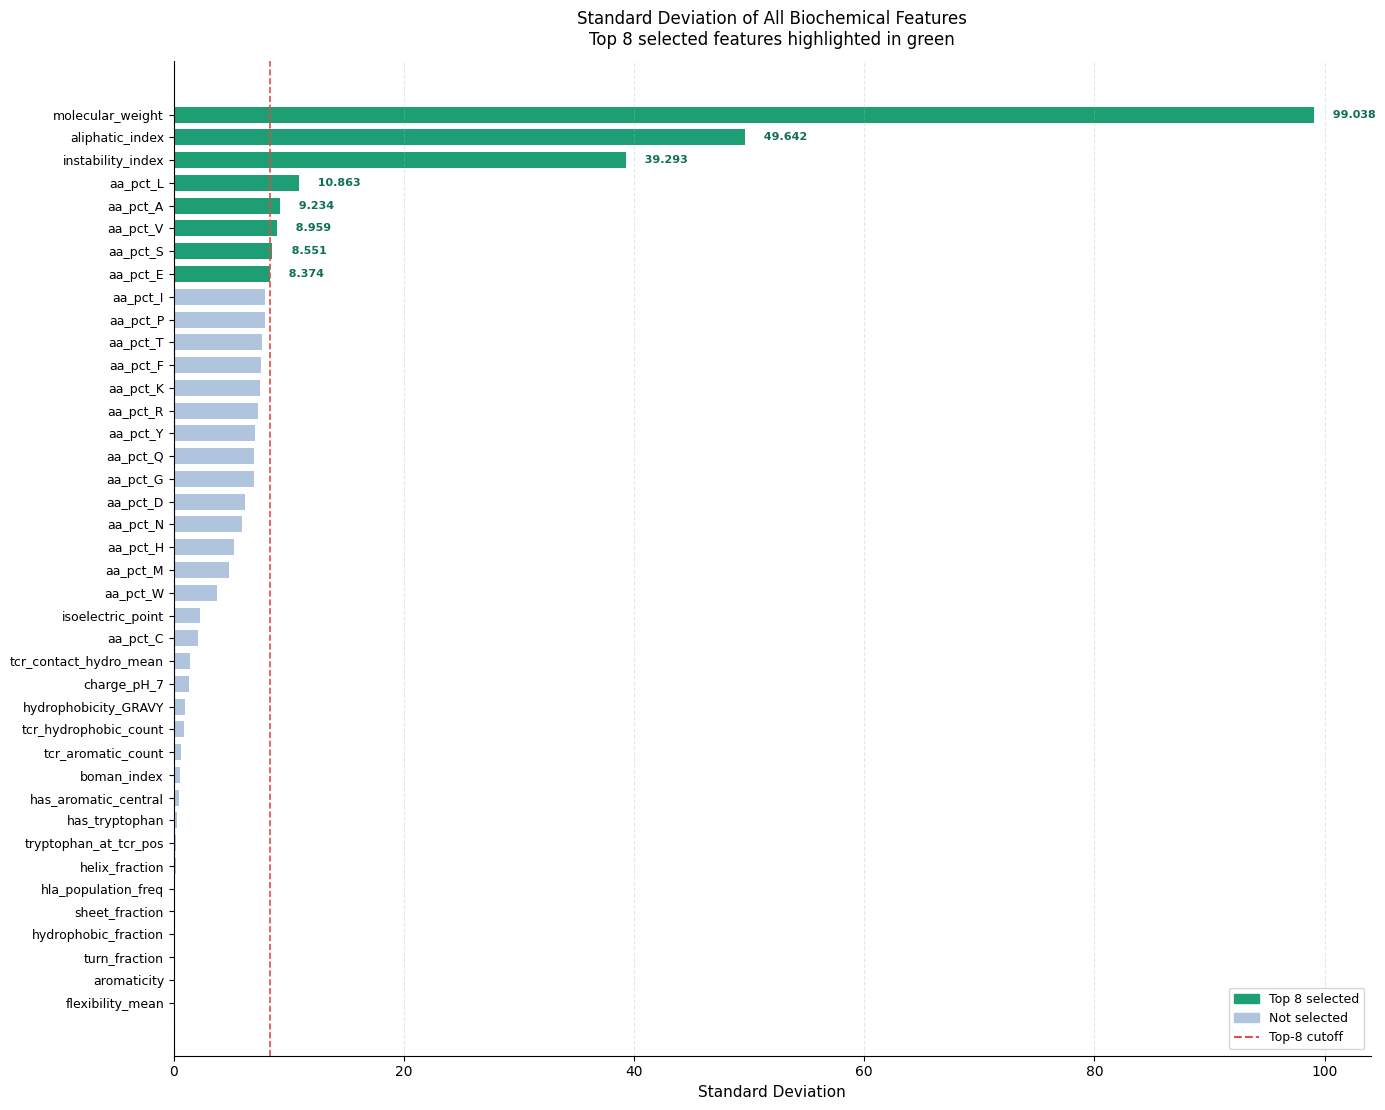

In [ ]:
fig, ax = plt.subplots(figsize=(14, max(6, len(sd_series) * 0.28)))

colors = ["#1D9E75" if f in top_features else "#B0C4DE" for f in sd_series.index]
ax.barh(range(len(sd_series)), sd_series.values, color=colors, edgecolor="none", height=0.7)
ax.set_yticks(range(len(sd_series)))
ax.set_yticklabels(sd_series.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Standard Deviation", fontsize=11)
ax.set_title(
    f"Standard Deviation of All Biochemical Features\n"
    f"Top {TOP_N_FEATURES_BY_SD} selected features highlighted in green",
    fontsize=12, pad=12
)
ax.axvline(
    sd_series.iloc[TOP_N_FEATURES_BY_SD - 1],
    color="#E24B4A", linestyle="--", linewidth=1.2
)
for i, feat in enumerate(sd_series.index):
    if feat in top_features:
        ax.text(
            sd_series[feat] + sd_series.max() * 0.01, i,
            f"  {sd_series[feat]:.3f}", va="center",
            fontsize=8, color="#0F6E56", fontweight="bold"
        )
top_patch  = mpatches.Patch(color="#1D9E75", label=f"Top {TOP_N_FEATURES_BY_SD} selected")
rest_patch = mpatches.Patch(color="#B0C4DE", label="Not selected")
cutoff_line = plt.Line2D([0],[0], color="#E24B4A", linestyle="--",
                         label=f"Top-{TOP_N_FEATURES_BY_SD} cutoff")
ax.legend(handles=[top_patch, rest_patch, cutoff_line], loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"✓ Saved: {OUTPUT_PATH}")
print(f"\nFinal dataset summary")
print(f"  Rows     : {len(df):,}")
print(f"  Columns  : {len(df.columns)}")
print(f"  Cancer   : {(df['is_cancer']==1).sum():,}  ({100*(df['is_cancer']==1).mean():.1f}%)")
print(f"  Healthy  : {(df['is_cancer']==0).sum():,}  ({100*(df['is_cancer']==0).mean():.1f}%)")
print(f"  Diseases : {df['Disease'].nunique()}")
print(f"  HLA alleles (known) : {df['Best HLA Allele'].nunique(dropna=True)}")
hla_pct = df["hla_known"].mean()*100 if "hla_known" in df.columns else 0
print(f"  HLA coverage : {hla_pct:.1f}%")
print(f"\nTop {TOP_N_FEATURES_BY_SD} features selected for model training:")
for f in top_features:
    print(f"  {f}")
df.head()

✓ Saved: /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_final2.csv

Final dataset summary
  Rows     : 944,391
  Columns  : 51
  Cancer   : 95,994  (10.2%)
  Healthy  : 848,397  (89.8%)
  Diseases : 14
  HLA alleles (known) : 200
  HLA coverage : 0.0%

Top 8 features selected for model training:
  molecular_weight
  aliphatic_index
  instability_index
  aa_pct_L
  aa_pct_A
  aa_pct_V
  aa_pct_S
  aa_pct_E


,Peptide Sequence,Best HLA Allele,Tissue,Disease,length,molecular_weight,charge_pH_7,hydrophobicity_GRAVY,isoelectric_point,oxidation_flag,...,aa_pct_N,aa_pct_P,aa_pct_Q,aa_pct_R,aa_pct_S,aa_pct_T,aa_pct_V,aa_pct_W,aa_pct_Y,is_cancer
0,KLEDLERDL,HLA-A*02:01,OTHER,healthy,9,1130.2489,-2.233045,-1.222222,4.316717,0,...,0.0,0.000000,0.0,11.111111,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,EVMPVSMAK,HLA-A*03:01,OTHER,healthy,9,991.2260,-0.164171,0.466667,6.100722,0,...,0.0,11.111111,0.0,0.000000,11.111111,0.000000,22.222222,0.0,0.0,0.0
5,EVMPVSMAK,HLA-A*11:01,OTHER,healthy,9,991.2260,-0.164171,0.466667,6.100722,0,...,0.0,11.111111,0.0,0.000000,11.111111,0.000000,22.222222,0.0,0.0,0.0
6,KTFPPTEPK,HLA-A*03:01,OTHER,healthy,9,1044.2011,0.760914,-1.633333,8.591073,0,...,0.0,33.333333,0.0,0.000000,0.000000,22.222222,0.000000,0.0,0.0,0.0
7,KTFPPTEPK,HLA-A*11:01,OTHER,healthy,9,1044.2011,0.760914,-1.633333,8.591073,0,...,0.0,33.333333,0.0,0.000000,0.000000,22.222222,0.000000,0.0,0.0,0.0
